In [71]:
# imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [72]:
%load_ext autoreload
%autoreload 2

import ev_metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
# Load the csv file
df = pd.read_csv('data/data.csv')

feature_names = df.columns[:-1].to_list()
features = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values
classes = np.unique(labels)

In [74]:
# ECM clustering
from evclust.ecm import ecm
model = ecm(x=features, c=2, beta = 1.1,  alpha=1, delta=3, disp=False)

F = model['F']
M = model['mass']

focal_sets = [" \\cup ".join(["\\omega_{" + str(i+1) + "}" for i in range(len(f)) if f[i] == 1]) for f in F]
focal_sets[0] = "\emptyset"
focal_sets = ['$'+f+'$' for f in focal_sets]

In [75]:
S_1 = ev_metrics.Utils.jaccard_matrix_calculus(M.shape[1])
upper_diagonal_ones = np.triu(np.ones((S_1.shape[0], S_1.shape[1])), k=0)
upper_S_1 = S_1 * upper_diagonal_ones
down_S_1 = upper_S_1.T

similarities_dict = {
    r"$down {S}^{-1/2}$": np.ceil(down_S_1) - 1/2*np.eye(down_S_1.shape[0]),
    r"$down {S}^{-0.4}$": np.ceil(down_S_1) - 0.4*np.eye(down_S_1.shape[0]),
    r"down ${S}^0$": np.ceil(down_S_1),
    r"down ${S}^{1/2}$": down_S_1**0.5,
    r"down ${S}^1$": down_S_1,
    r"down ${S}^2$": down_S_1**2,
    "$S^\infty$": np.floor(S_1),
}

In [76]:
similarities = list(similarities_dict.values())
similarity_names = list(similarities_dict.keys())
assignabilities = [ev_metrics.Assignability.from_matrix(similarity) for similarity in similarities]
metrics_builder = ev_metrics.EvidentialMetrics(F, features)
silhouette_fns = [metrics_builder.get_silhouette(assignability) for assignability in assignabilities]
assignabilities_names = similarity_names

In [77]:
# coefs_dict = [
#     (0, 1),
#     (30, 1),
# ]

# assignabilities.extend(
#     [
#         ev_metrics.Assignability.cost_based(
#             F, coefs_dict[i][0], coefs_dict[i][1])
#     for i in range(len(coefs_dict))
#     ]
# )
# assignabilities_names = similarity_names + [f"cost-based {coefs_dict[i][0]},{coefs_dict[i][1]}" for i in range(len(coefs_dict))]
# silhouette_fns.extend(
#     [
#         metrics_builder.get_silhouette(assignabilities[len(similarities) + i])
#     for i in range(len(coefs_dict))
#     ]
# )

In [78]:
def plot_parameters(alpha, beta, delta, ax):
    model = ecm(x=features, c=2, beta = beta,  alpha=alpha, delta=delta, disp=False)
    memberships = model['mass']
    N = memberships.shape[1]

    # get list of colors 
    cmap = plt.get_cmap('Set1')

    def_avg_sillhouettes = [sillhouette_fn(memberships) for sillhouette_fn in silhouette_fns]
    str_avg_sillhouettes = [f'{assignabilities_names[n]} = {s:.2f}' for n, s in enumerate(def_avg_sillhouettes)]
    str_avg_sillhouettes = '\n'.join(str_avg_sillhouettes)

    ax.set_yticks([])
    ax.set_xticks([])

    for point in range(len(features)):
        color = np.sum([np.array(cmap(i)) * memberships[point, i] for i in range(N)], axis=0)
        color = np.clip(color, 0, 1)
    
        ax.scatter(features[point, 0], features[point, 1], c=[color], edgecolors='k')

    ax.set_title(f'$\\alpha={alpha}$, $\\beta={beta}$, $\\delta={delta}$\n{str_avg_sillhouettes}')

In [79]:
np.repeat(F.sum(axis=1).reshape(-1, 1), M.shape[0], axis=1).shape

(4, 202)

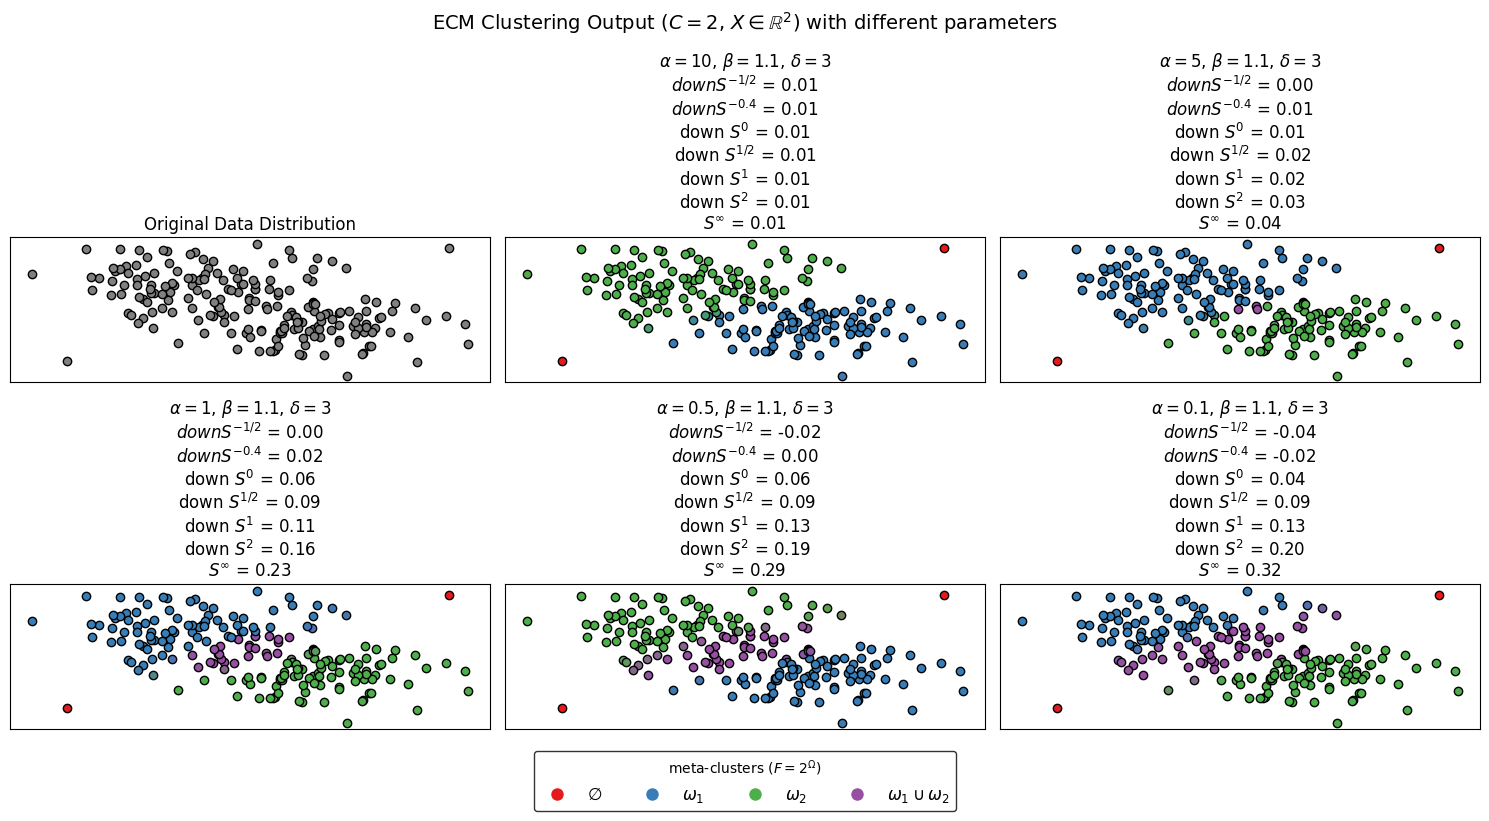

In [80]:
pars = [
    (10, 1.1, 3),
    (5, 1.1, 3),
    (1, 1.1, 3),
    (0.5, 1.1, 3),
    (0.1, 1.1, 3),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 7.5))


# scatter in gray
for point in range(len(features)):
    axs[0, 0].scatter(features[point, 0], features[point, 1], c='gray', edgecolors='k')
    axs[0, 0].set_yticks([])
    axs[0, 0].set_xticks([])
    axs[0, 0].set_title('Original Data Distribution')

for i in range(len(pars)):
    i +=1
    plot_parameters(*pars[i-1], axs[i//3, i%3])

fig.suptitle('ECM Clustering Output ($C=2$, $X \in \mathbb{R}^2$) with different parameters', fontsize=14)

fig.tight_layout()

fig.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=focal_sets[i], 
                                    markerfacecolor=plt.get_cmap('Set1')(i), markersize=10) for i in range(len(focal_sets))],edgecolor='black', 
                loc='lower center', ncol=len(focal_sets), fontsize='large', title='meta-clusters ($F = 2^\Omega$)', bbox_to_anchor=(0.5, -0.1))
        


In [81]:
# pars_default = (1, 2, 3)
pars_default = (1, 1.1, 3)

# var pars and measure sillhouettes
sillhouettes = []

# variate alpha
# for alpha in [0.1, 0.5, 1, 2, 5, 10]:
for alpha in np.linspace(0.01, 10, 100):
    try:
        model = ecm(x=features, c=2, beta = pars_default[1],  alpha=alpha, delta=pars_default[2], disp=False)
        memberships = model['mass']
        out = [silhouette_fn(memberships) for silhouette_fn in silhouette_fns]
        out = {f'{assignabilities_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': alpha, 'beta': pars_default[1], 'delta': pars_default[2], **out})
    except:
        pass

# variate beta
# for beta in [1.01, 1.1, 1.5, 2, 5, 10]:
for beta in np.linspace(1.01, 8, 40):
    try:
        model = ecm(x=features, c=2, beta = beta,  alpha=pars_default[0], delta=pars_default[2], disp=False)
        memberships = model['mass']
        out = [silhouette_fn(memberships) for silhouette_fn in silhouette_fns]
        out = {f'{assignabilities_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': pars_default[0], 'beta': beta, 'delta': pars_default[2], **out})
    except:
        pass
    
# variate delta
# for delta in [0.1, 0.5, 1, 2, 5, 10]:
for delta in np.linspace(0.1, 8, 100):
    try:
        model = ecm(x=features, c=2, beta = pars_default[1],  alpha=pars_default[0], delta=delta, disp=False)
        memberships = model['mass']
        out = [silhouette_fn(memberships) for silhouette_fn in silhouette_fns]
        out = {f'{assignabilities_names[n]}': s for n, s in enumerate(out)}
        sillhouettes.append({'alpha': pars_default[0], 'beta': pars_default[1], 'delta': delta, **out})
    except:
        pass

sillhouettes = pd.DataFrame(sillhouettes)
sillhouettes

/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:121: RuntimeWarning: overflow encountered in power
  vect1 = (np.tile(D[i, j], f-1) / vect0) ** (1 / (beta-1))
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:123: RuntimeWarning: overflow encountered in multiply
  vect3 = vect1 * vect2
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/utils.py:205: RuntimeWarning: divide by zero encountered in divide
  C = 1 / (1 - conf)
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:163: RuntimeWarning: invalid value encountered in power
  J = np.nansum((m ** beta) * D[:, :f - 1] * np.tile(card[:f - 1] ** alpha, (n, 1))) + delta2 * np.nansum(mvide[:f - 1] ** beta)


,alpha,beta,delta,$down {S}^{-1/2}$,$down {S}^{-0.4}$,down ${S}^0$,down ${S}^{1/2}$,down ${S}^1$,down ${S}^2$,$S^\infty$
0,0.010000,1.1,3.000000,-0.039323,-0.020747,0.038774,0.082446,0.125054,0.198057,0.322955
1,0.110909,1.1,3.000000,-0.034631,-0.015912,0.043412,0.086434,0.128064,0.199337,0.320869
2,0.211818,1.1,3.000000,-0.030668,-0.012004,0.046798,0.089021,0.129567,0.199116,0.317334
3,0.312727,1.1,3.000000,-0.026937,-0.008432,0.049528,0.090681,0.130059,0.197562,0.311782
4,0.413636,1.1,3.000000,-0.022751,-0.004334,0.052437,0.092062,0.129936,0.194559,0.303122
...,...,...,...,...,...,...,...,...,...,...
235,1.000000,1.1,7.680808,-0.022600,-0.008127,0.032834,0.059585,0.084372,0.125928,0.195043
236,1.000000,1.1,7.760606,-0.022600,-0.008127,0.032834,0.059585,0.084372,0.125928,0.195043
237,1.000000,1.1,7.840404,-0.022600,-0.008127,0.032834,0.059585,0.084372,0.125928,0.195043
238,1.000000,1.1,7.920202,-0.022600,-0.008127,0.032834,0.059585,0.084372,0.125928,0.195043


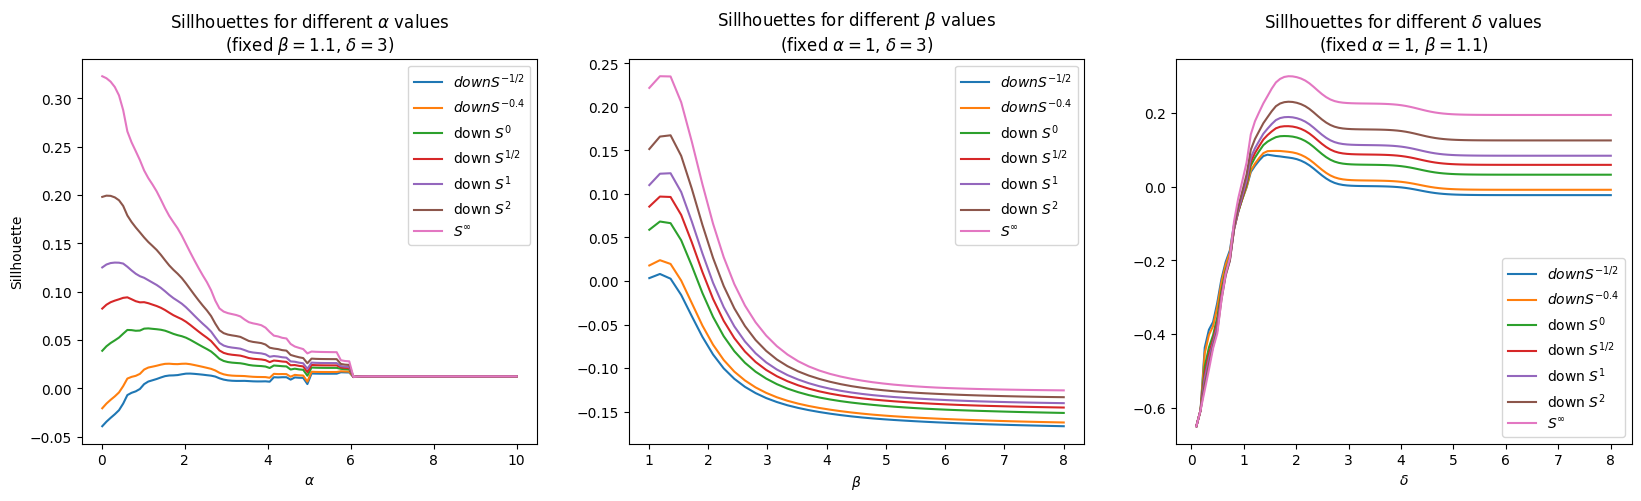

In [82]:
# plot sillhouettes
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# fix beta and delta
to_plot = sillhouettes[(sillhouettes['beta'] == pars_default[1]) & (sillhouettes['delta'] == pars_default[2])].sort_values('alpha')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[0].plot(to_plot['alpha'], to_plot[c], label=c)
axs[0].set_title(f'Sillhouettes for different $\\alpha$ values\n(fixed $\\beta={pars_default[1]}$, $\\delta={pars_default[2]}$)')
axs[0].set_xlabel('$\\alpha$')
axs[0].set_ylabel('Sillhouette')
axs[0].legend()
# log scale
# axs[0].set_xscale('log')

# fix alpha and delta
to_plot = sillhouettes[(sillhouettes['alpha'] == pars_default[0]) & (sillhouettes['delta'] == pars_default[2])].sort_values('beta')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[1].plot(to_plot['beta'], to_plot[c], label=c)
axs[1].set_title(f'Sillhouettes for different $\\beta$ values\n(fixed $\\alpha={pars_default[0]}$, $\\delta={pars_default[2]}$)')
axs[1].set_xlabel('$\\beta$')
axs[1].legend()

# fix alpha and beta
to_plot = sillhouettes[(sillhouettes['alpha'] == pars_default[0]) & (sillhouettes['beta'] == pars_default[1])].sort_values('delta')
for c in to_plot.columns:
    if c == 'alpha' or c == 'beta' or c == 'delta':
        continue
    axs[2].plot(to_plot['delta'], to_plot[c], label=c)
axs[2].set_title(f'Sillhouettes for different $\\delta$ values\n(fixed $\\alpha={pars_default[0]}$, $\\beta={pars_default[1]}$)')
axs[2].set_xlabel('$\\delta$')
axs[2].legend()

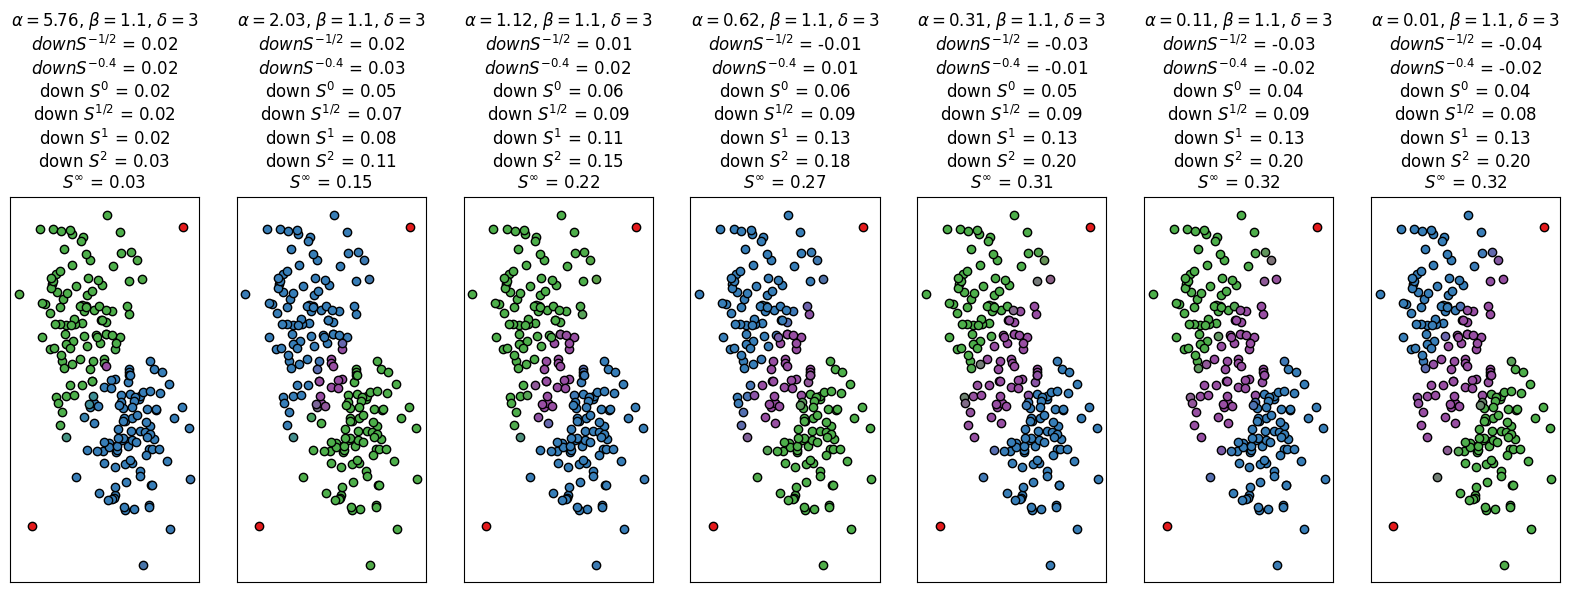

In [83]:
# for each Sillhouette, plot the alpha that maximizes it
fig, axs = plt.subplots(1, len(assignabilities_names), figsize=(20, 5))
to_plot = sillhouettes[(sillhouettes['beta'] == pars_default[1]) & (sillhouettes['delta'] == pars_default[2])].sort_values('alpha')
i = 0
for s in assignabilities_names:
    # get the max alpha for each similarity
    max_alpha = to_plot[s].idxmax()
    max_alpha = to_plot['alpha'].iloc[max_alpha]
    # just two decimal points
    max_alpha = round(max_alpha, 2)
    pars = (max_alpha, pars_default[1], pars_default[2])
    # plot the alpha
    i += 1
    plot_parameters(*pars, axs[i-1])